In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import os

# ====================
# Config
# ====================
latent_dim = 100
img_size = 28
channels = 1
batch_size = 64
epochs = 100
n_critic = 5         # Critic steps per generator step
clip_value = 0.01    # Weight clipping
lr = 0.00005         # Learning rate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("images_wgan", exist_ok=True)

# ====================
# Data Loader
# ====================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Scale to [-1, 1]
])

dataloader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# ====================
# Models
# ====================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), 1, img_size, img_size)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(img_size * img_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)  # No sigmoid
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

# ====================
# Initialize models
# ====================
generator = Generator().to(device)
critic = Critic().to(device)

optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
optimizer_C = optim.RMSprop(critic.parameters(), lr=lr)

# Loss trackers
gen_losses = []
critic_losses = []

# ====================
# Training
# ====================
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        real_imgs = imgs.to(device)

        # ---------------------
        # Train Critic
        # ---------------------
        optimizer_C.zero_grad()

        z = torch.randn(imgs.size(0), latent_dim, device=device)
        fake_imgs = generator(z)

        loss_C = -torch.mean(critic(real_imgs)) + torch.mean(critic(fake_imgs.detach()))
        loss_C.backward()
        optimizer_C.step()

        # Weight clipping for Lipschitz constraint
        for p in critic.parameters():
            p.data.clamp_(-clip_value, clip_value)

        # ---------------------
        # Train Generator every n_critic steps
        # ---------------------
        if i % n_critic == 0:
            optimizer_G.zero_grad()

            z = torch.randn(imgs.size(0), latent_dim, device=device)
            gen_imgs = generator(z)
            loss_G = -torch.mean(critic(gen_imgs))
            loss_G.backward()
            optimizer_G.step()

    # Save epoch losses
    gen_losses.append(loss_G.item())
    critic_losses.append(loss_C.item())

    print(f"[Epoch {epoch+1}/{epochs}] C loss: {loss_C.item():.4f} | G loss: {loss_G.item():.4f}")

    # Save generated images
    save_image(gen_imgs.data[:25], f"images_wgan/{epoch+1}.png", nrow=5, normalize=True)

print("Training Complete — WGAN results saved in 'images_wgan/' folder")


[Epoch 1/100] C loss: -0.1132 | G loss: -15.8931
[Epoch 2/100] C loss: -0.0168 | G loss: -13.5210
[Epoch 3/100] C loss: -0.0022 | G loss: -11.2058
[Epoch 4/100] C loss: 0.0017 | G loss: -8.9102
[Epoch 5/100] C loss: 0.0235 | G loss: -8.2603
[Epoch 6/100] C loss: 0.0124 | G loss: -6.9072
[Epoch 7/100] C loss: -0.0243 | G loss: -5.6494
[Epoch 8/100] C loss: -0.0165 | G loss: -4.2433
[Epoch 9/100] C loss: 0.0256 | G loss: -2.4841
[Epoch 10/100] C loss: -0.0366 | G loss: -2.2918
[Epoch 11/100] C loss: -0.0678 | G loss: -2.7458
[Epoch 12/100] C loss: -0.0558 | G loss: -2.1567
[Epoch 13/100] C loss: -0.0693 | G loss: -0.2137
[Epoch 14/100] C loss: -0.1690 | G loss: 0.9860
[Epoch 15/100] C loss: -0.0956 | G loss: -0.4478
[Epoch 16/100] C loss: -0.0956 | G loss: -0.9186
[Epoch 17/100] C loss: -0.1252 | G loss: -1.4332
[Epoch 18/100] C loss: -0.1362 | G loss: 0.3249
[Epoch 19/100] C loss: -0.1758 | G loss: 0.1532
[Epoch 20/100] C loss: -0.1615 | G loss: 0.3210
[Epoch 21/100] C loss: -0.1616 | G

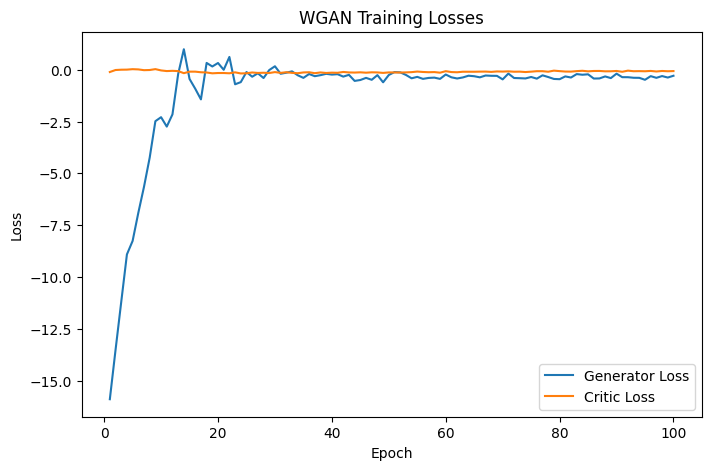

In [25]:
# ====================
# Plot Losses
# ====================
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), gen_losses, label="Generator Loss")
plt.plot(range(1, epochs+1), critic_losses, label="Critic Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN Training Losses")
plt.legend()
plt.savefig("wgan_losses.png")
plt.show()

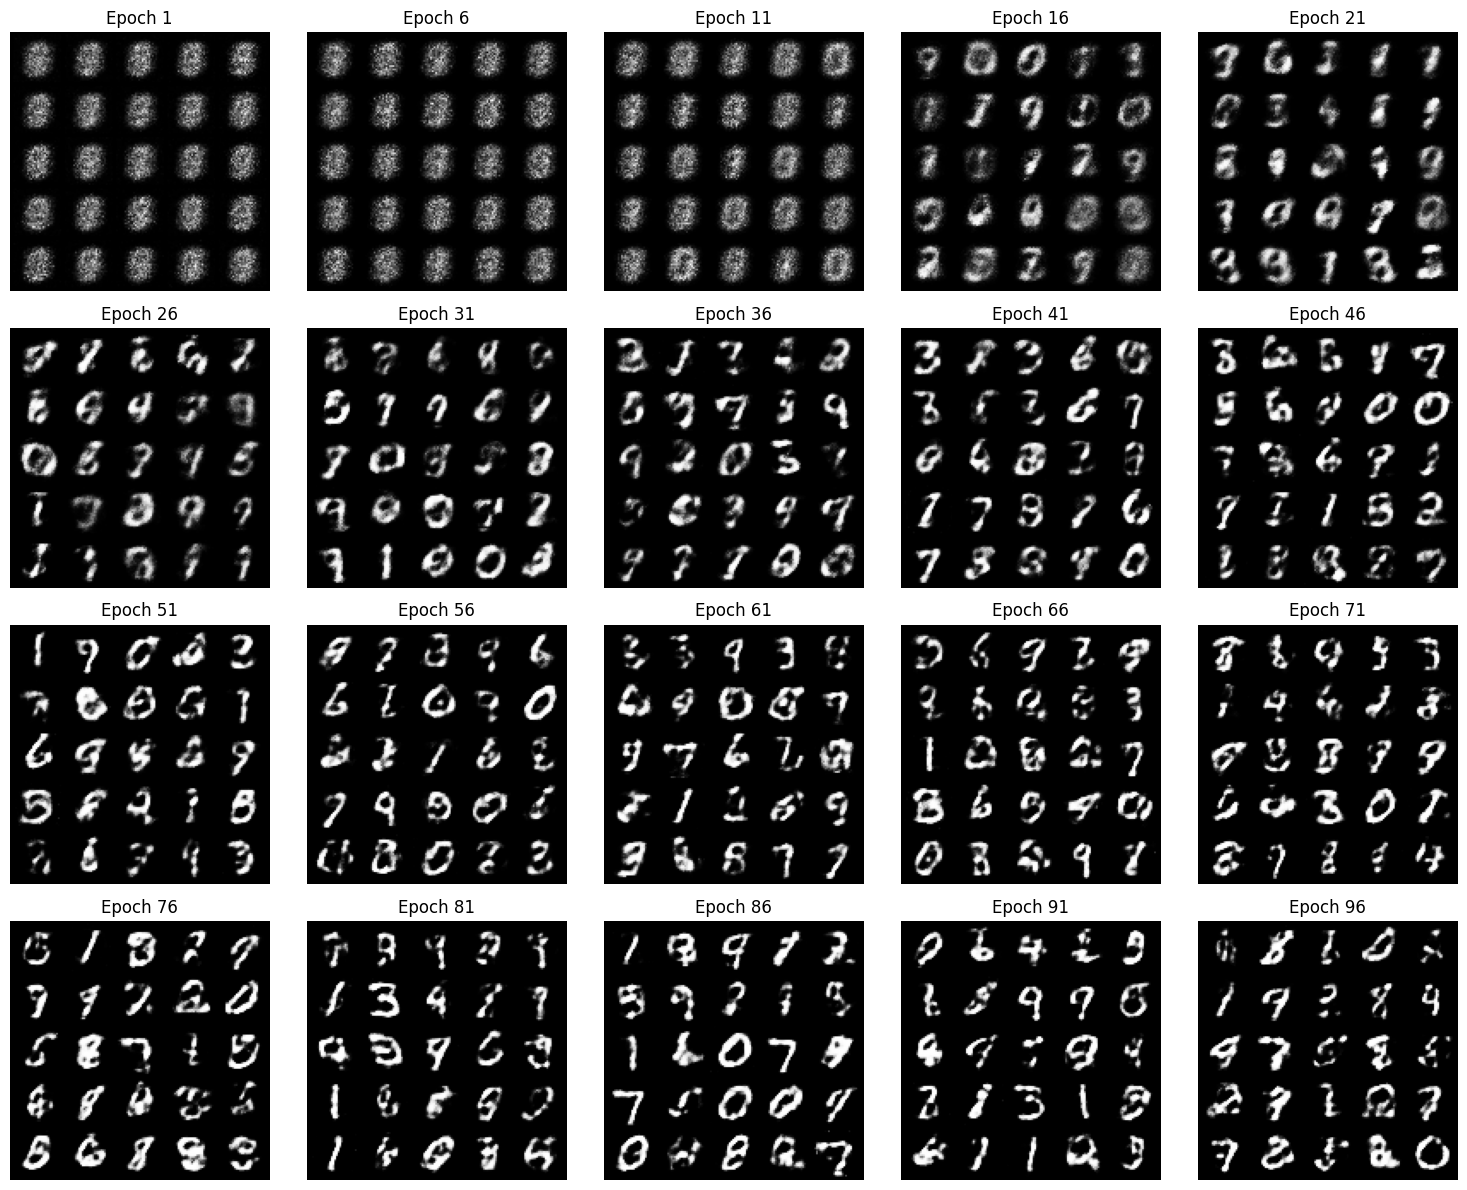

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = "images_wgan"
epochs = 100
step = 5

# Collect epochs to display
selected_epochs = list(range(1, epochs+1, step))

# Calculate grid size
cols = 5  # number of images per row
rows = (len(selected_epochs) + cols - 1) // cols

# Prepare the figure
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))

for idx, epoch in enumerate(selected_epochs):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]

    img_path = os.path.join(folder, f"{epoch}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
    ax.axis('off')

# Turn off any empty subplots
for i in range(len(selected_epochs), rows*cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis('off')

plt.tight_layout()
plt.savefig("wgan_progress_every5.png")
plt.show()
